# Customer Retention Strategy Analysis

## Objective
The goal of this project is to analyze customer churn patterns and identify factors that contribute to customer attrition. Insights from this analysis can help improve retention strategies and reduce revenue loss.

## Tools Used
- Python (Pandas, Matplotlib)
- Jupyter Notebook
- Power BI

In [1]:
import pandas as pd

df = pd.read_csv("/Users/vinaypolaku/Downloads/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0.0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7041 non-null   float64
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7041.000000,7043.000000,7043.000000
mean,0.162193,32.371149,64.761692
std,0.368654,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       2
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Data Quality Findings

The dataset contains only 2 missing values in the SeniorCitizen column and no duplicate records. Overall, the dataset is clean and suitable for analysis.

In [14]:
total_customers=len(df)
churned_customers= (df["Churn"]=="Yes").sum()
churn_rate = churned_customers/total_customers
print(f"Churn Rate: {churn_rate:.2%}")

Churn Rate: 26.54%


In [15]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Churn Overview

Approximately 26.5% of customers have churned, while 73.5% remain active. This indicates that roughly one out of every four customers leaves the company.

In [16]:
df["ChurnFlag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [18]:
df.groupby("Contract")["ChurnFlag"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: ChurnFlag, dtype: float64

In [19]:
df.groupby("PaymentMethod")["ChurnFlag"].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: ChurnFlag, dtype: float64

## Payment Method Impact

Customers using electronic checks experience the highest churn rate at 45.3%. Automatic payment methods such as credit cards and bank transfers are associated with lower churn rates.

In [22]:
df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"],
    errors = "coerce"
)
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64

In [25]:
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"],
    include_lowest=True
)

df.groupby("TenureGroup")["ChurnFlag"].mean()

TenureGroup
0-12     0.474382
13-24    0.287109
25-48    0.203890
49-72    0.095132
Name: ChurnFlag, dtype: float64

In [36]:
df.groupby("Churn")["MonthlyCharges"].sum()

Churn
No     316985.75
Yes    139130.85
Name: MonthlyCharges, dtype: float64

In [38]:

churn_revenue_pct=(
    df[df["Churn"]=="Yes"]["MonthlyCharges"].sum()
    / df["MonthlyCharges"].sum()
)
print(f"{churn_revenue_pct:.2%}")

30.50%


## Revenue Impact of Churn

Although churned customers account for only 26.5% of the customer base, they represent 30.5% of monthly recurring revenue. Reducing churn could have a meaningful financial impact on the business.

In [41]:
df.groupby("Churn")[["tenure","MonthlyCharges","TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2555.344141
Yes,17.979133,74.441332,1531.796094


## Churned vs Non-Churned Customers

Churned customers have shorter average tenure (18 months vs 38 months) and higher monthly charges ($74 vs $61). This suggests that newer customers with higher bills are more likely to leave.

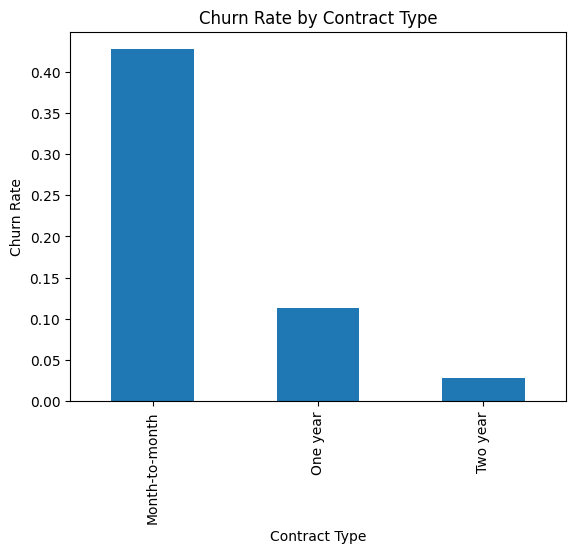

In [45]:
import matplotlib.pyplot as plt

contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .mean()
      .sort_values(ascending=False)
)

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

## Contract Type Impact

Customers on month-to-month contracts have the highest churn rate at 42.7%, compared to only 2.8% for customers on two-year contracts. Longer-term contracts appear to significantly improve customer retention.

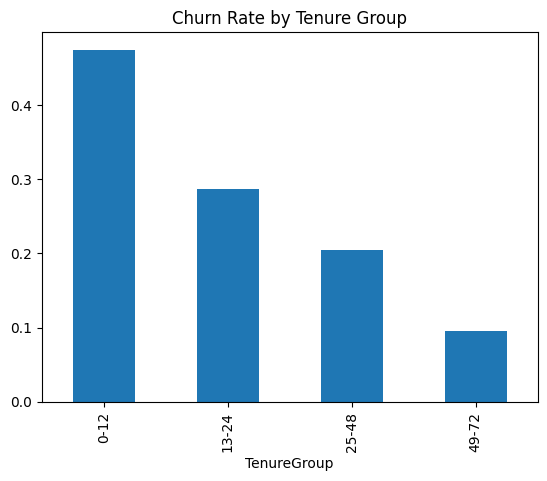

In [46]:
df.groupby("TenureGroup")["ChurnFlag"].mean().plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.show()

## Customer Tenure Impact

Customers with less than 12 months of tenure have the highest churn rate at 47.4%. Churn steadily decreases as customer tenure increases, suggesting retention efforts should focus on newer customers.

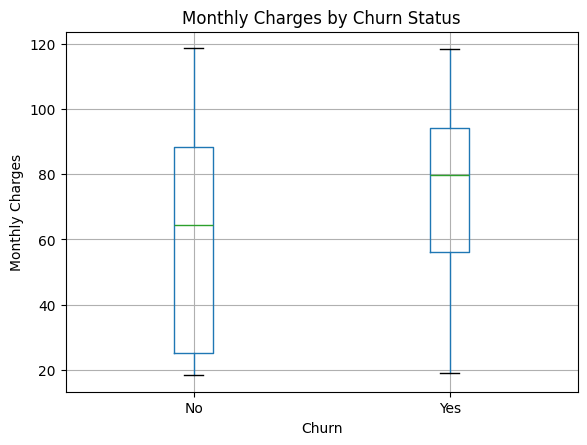

In [48]:
import matplotlib.pyplot as plt

df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Monthly Charges by Churn Status")
plt.suptitle("")  # removes extra pandas title
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

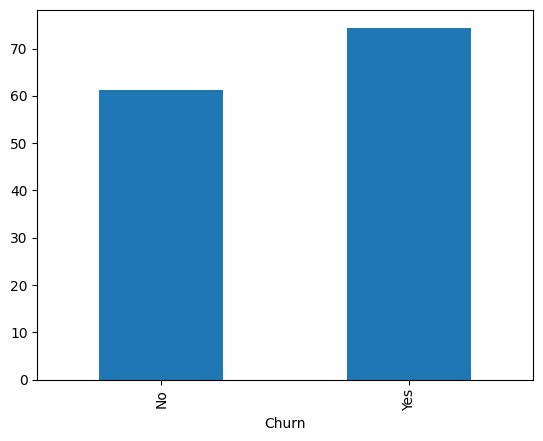

In [53]:
df.groupby("Churn")["MonthlyCharges"].mean().plot(kind="bar")
plt.show()

# Key Business Recommendations

1. Encourage month-to-month customers to switch to longer-term contracts.
2. Focus retention campaigns on customers within their first year.
3. Investigate why electronic check customers churn at significantly higher rates.
4. Identify high-bill customers and offer targeted retention incentives.
5. Develop onboarding programs to improve retention among new customers.

# Conclusion

Customer churn is strongly associated with contract type, tenure, payment method, and monthly charges. Month-to-month customers, newer customers, and customers using electronic checks exhibit significantly higher churn rates. By targeting these customer segments with retention initiatives, the company can reduce churn and protect recurring revenue.